# Garanti BBVA BES — What I Got Wrong, and How I Fixed It
# Garanti BBVA BES — Neyi Yanlış Yaptım, Nasıl Düzelttim

**EN —** In May 2024 I entered the Garanti BBVA Data Day case study on Kaggle: predict each
customer's **BES additional contribution** (`ADDCONTAMNT`, the extra money a customer puts into
their private pension on top of the regular plan) for December 2018. The metric was RMSE. I finished
**11th of 51**.

Two years later I went back to that notebook ([`00_original_2024.ipynb`](00_original_2024.ipynb)) with
one question: *what exactly did I do wrong?* This notebook is the answer. Every claim below is
measured with the same validation, and the logic lives in `src/` (run `python train.py` first; it
writes the tables and figures this notebook reads).

**TR —** Mayıs 2024'te Kaggle'daki Garanti BBVA Data Day vakasına katıldım. Görev, her müşterinin
Aralık 2018'deki **BES ek katkı payını** (`ADDCONTAMNT`, müşterinin düzenli planının üstüne
emeklilik hesabına yatırdığı ek para) tahmin etmekti; metrik RMSE'ydi. **51 kişi içinde 11.** oldum.

İki yıl sonra o notebook'a ([`00_original_2024.ipynb`](00_original_2024.ipynb)) tek bir soruyla geri
döndüm: *tam olarak neyi yanlış yaptım?* Bu notebook o sorunun cevabı. Aşağıdaki her iddia aynı
doğrulama yöntemiyle ölçüldü; mantık `src/` içinde duruyor (önce `python train.py` çalıştırın,
bu notebook'un okuduğu tabloları ve grafikleri o üretiyor).

## 1. Setup / Kurulum

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import config
from src.data import load_train, load_test, raw_feature_columns

pd.set_option("display.float_format", "{:,.1f}".format)
train, test = load_train(), load_test()
results = pd.read_csv(config.REPORTS_DIR / "results.csv")
checks = pd.read_csv(config.REPORTS_DIR / "checks.csv")
metrics = json.loads((config.MODELS_DIR / "metrics.json").read_text(encoding="utf-8"))
fig = lambda name: display(Image(filename=str(config.FIGURES_DIR / name)))

## 2. The data, in numbers / Sayılarla veri

**EN —** Train is a stack of month-end snapshots (March–November 2018). A customer can appear in
several months; the test is one snapshot, December 2018. I only print aggregates here: the data
belongs to the competition and is not mine to republish.

**TR —** Train, ay sonu anlık görüntülerinin (Mart–Kasım 2018) üst üste binmesi. Bir müşteri birden
fazla ayda görünebiliyor; test ise tek bir anlık görüntü, Aralık 2018. Burada sadece toplu sayılar
yazdırıyorum: veri yarışmaya ait, benim yeniden yayınlayabileceğim bir şey değil.

In [2]:
per_month = train.groupby(config.MONTH)[config.TARGET].agg(
    rows="size", contributes_pct=lambda s: 100 * (s > 0).mean(), mean="mean", max="max")
print(f"train: {len(train):,} rows, {train[config.ID].nunique():,} customers")
print(f"test : {len(test):,} customers (Dec), {test[config.ID].isin(train[config.ID]).sum():,} of them seen in train")
per_month

train: 173,589 rows, 155,404 customers
test : 16,978 customers (Dec), 3,782 of them seen in train


,rows,contributes_pct,mean,max
month,,,,
3,19180,10.0,"1,106.0",900100
4,18469,10.0,867.8,1260100
5,17520,10.0,735.4,1200100
6,16380,10.0,625.4,139988
7,15800,10.0,586.3,360100
8,15890,10.0,736.2,1020100
9,16330,10.0,533.4,150100
10,20230,10.0,667.0,583300
11,33790,10.0,958.2,360100


**EN —** Two things jump out, and I missed both in 2024:

1. **Exactly 10.0% of rows contribute, in every single month.** Real behaviour is never that tidy,
   so the organisers sampled 1 contributor for every 9 non-contributors. The test is almost
   certainly built the same way.
2. **The target is 90% zeros with a monstrous tail.** The mean is ~780, but single rows reach 1.26
   million. Under RMSE, that tail is the whole game (section 3).

**TR —** İki şey hemen göze çarpıyor ve 2024'te ikisini de kaçırmışım:

1. **Her ayda satırların tam %10,0'ı katkı yapıyor.** Gerçek davranış hiç bu kadar düzenli olmaz;
   demek ki organizatörler her 9 katkısız satıra 1 katkılı satır örneklemiş. Test de büyük ihtimalle
   aynı şekilde kurulmuş.
2. **Hedefin %90'ı sıfır ve kuyruğu devasa.** Ortalama ~780, ama tek bir satır 1,26 milyona çıkıyor.
   RMSE altında oyunun tamamı bu kuyruk (bölüm 3).

In [3]:
mins = train[raw_feature_columns(train)].min()
print("columns whose minimum is exactly 100:", (mins == 100).sum(), "of", len(mins))
mins[mins == 100].index.tolist()

columns whose minimum is exactly 100: 17 of 36


['ACCMVMTAVG',
 'ACCAMNTAVG03',
 'CARDDINSUM12',
 'DISTNUM12',
 'INTPHNNUM03',
 'INTLOGNUM12',
 'BLNAMNT03',
 'CRRASTALL',
 'EFTAMNTSUM12',
 'MAXMATEVR',
 'DEBTAVG00',
 'LSTPRDCNUM',
 'DESACCUAMNT',
 'CONTDEBTNUM',
 'MAXTIMECONTR',
 'CONTCOLLAMNT',
 'LASTAUTOPAYTIME']

**EN —** A third quirk: 17 of the 36 columns bottom out at exactly **100**, which looks like the
anonymisation added a constant. In 2024 I filled every missing value with `0` — *below* the real
floor — which is harmless for trees but distorts a linear model. The rebuild leaves NaNs as NaN and
lets LightGBM learn what "missing" means.

**TR —** Üçüncü bir tuhaflık: 36 sütunun 17'si tam **100**'de dipte kalıyor. Anonimleştirme
değerlere sabit bir sayı eklemiş gibi görünüyor. 2024'te tüm eksik değerleri `0` ile doldurmuşum,
yani gerçek tabanın *altına*. Bu, ağaç modelleri için zararsız ama doğrusal modeli bozuyor. Yeni
sürümde NaN'lar NaN olarak kalıyor ve "eksik"in ne anlama geldiğini LightGBM kendisi öğreniyor.

## 3. RMSE here is a whale hunt / Burada RMSE bir balina avı

**EN —** How much of each month's squared error comes from its 10 biggest rows (out of 15–34
thousand)?

**TR —** Her ayın karesel hatasının ne kadarı, (15–34 bin satır arasından) en büyük 10 satırdan
geliyor?

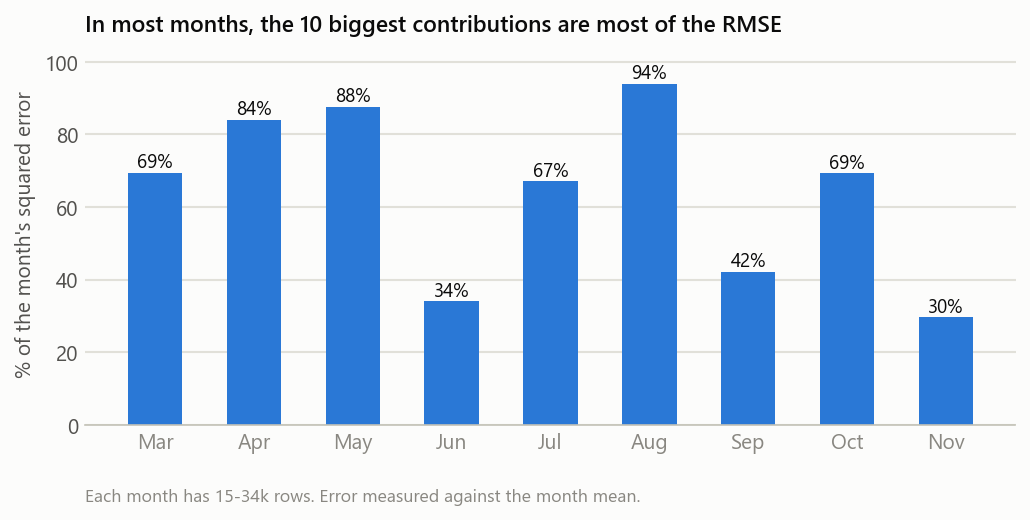

,3,4,5,6,7,8,9,10,11
top-10 share %,69.0,84.0,88.0,34.0,67.0,94.0,42.0,69.0,30.0


In [4]:
fig("whale_share.png")
pd.Series(metrics["top10_share_of_squared_error_by_month"]).mul(100).round(0).rename("top-10 share %").to_frame().T

**EN —** In April one single row is three quarters of the month's squared error. Nobody can
predict a 1.2 million contribution from these features, so every model's RMSE is mostly "how
badly did I miss the whales". Three consequences shaped everything below:

* **Improvements look small.** A model that is genuinely better will still only shave a few
  percent off RMSE.
* **One month is a lottery ticket.** A single validation month can flip a conclusion, so I pool
  five months (June–October) for every decision.
* **Predicting the mean is a tough baseline.** It is the best constant under RMSE, and I never
  compared against it in 2024.

**TR —** Nisan'da tek bir satır, ayın karesel hatasının dörtte üçü. Bu özelliklerle 1,2 milyonluk
bir katkıyı kimse tahmin edemez; o yüzden her modelin RMSE'si büyük ölçüde "balinaları ne kadar
kaçırdım"dan ibaret. Aşağıdaki her şeyi üç sonuç belirledi:

* **İyileşmeler küçük görünür.** Gerçekten daha iyi bir model bile RMSE'den ancak birkaç yüzde kırpar.
* **Tek ay bir piyango biletidir.** Tek bir doğrulama ayı sonucu tersine çevirebilir; bu yüzden her
  kararı beş ayı (Haziran–Ekim) birlikte değerlendirerek veriyorum.
* **Ortalamayı tahmin etmek zorlu bir baseline'dır.** RMSE altında en iyi sabit tahmin odur ve 2024'te
  onunla hiç kıyaslamadım.

## 4. How I validate now / Artık nasıl doğruluyorum

**EN —** The real task is "history up to November → predict December". So to score month *m* I
train only on months before *m* (rolling origin). June–October are my **dev** months: every choice
(model, features, Tweedie power) was made on their pooled RMSE. **November is the holdout**; it
had no say in any choice. Every number is also shown relative to the mean baseline, because a raw
RMSE of "6,400" means nothing on its own.

**TR —** Gerçek görev "Kasım'a kadarki geçmiş → Aralık'ı tahmin et". Bu yüzden *m* ayını
puanlarken sadece *m*'den önceki aylarla eğitiyorum (rolling origin). Haziran–Ekim **dev** aylarım:
her seçim (model, özellikler, Tweedie parametresi) bu ayların birleşik RMSE'sine göre yapıldı.
**Kasım holdout**; hiçbir seçimde söz hakkı olmadı. Her sayıyı ortalama baseline'a göre de
veriyorum, çünkü tek başına "6.400" gibi bir RMSE hiçbir şey ifade etmiyor.

## 5. The mistakes / Hatalar

### Mistake 1 — I never compared against a baseline / Hata 1 — Hiç baseline ile kıyaslamadım

In [5]:
cols = ["label", "dev_rmse", "dev_vs_mean_pct", "dev_months_beating_mean", "holdout_rmse", "holdout_vs_mean_pct"]
results.loc[results.key.isin(["0_mean", "1_as_submitted"]), cols]

,label,dev_rmse,dev_vs_mean_pct,dev_months_beating_mean,holdout_rmse,holdout_vs_mean_pct
0,Baseline: predict the training mean,"6,817.1",0.0,0,"5,160.0",0.0
1,"My 2024 notebook, replayed exactly","7,413.4",8.7,2,"5,200.8",0.8


**EN —** This is the one that stings. Replayed under honest validation, my 2024 notebook is
**8.7% worse than predicting the same number for everyone**, and it only beats that constant in 2
of the 5 dev months. `src/original.py` reproduces the notebook exactly (it matches the predictions
the notebook printed), so this is my real model, not a strawman.

**TR —** En çok acıtan bu. Dürüst doğrulamayla tekrar çalıştırıldığında 2024 notebook'um,
**herkese aynı sayıyı tahmin etmekten %8,7 daha kötü**; o sabiti 5 dev ayının sadece 2'sinde
geçebiliyor. `src/original.py` notebook'u birebir tekrar ediyor (notebook'un yazdırdığı tahminlerle
aynı çıkıyor); yani bu bir karikatür değil, gerçekten benim modelim.

### Mistake 2 — My cross-validation told me a comforting story / Hata 2 — Çapraz doğrulamam bana rahatlatıcı bir hikâye anlattı

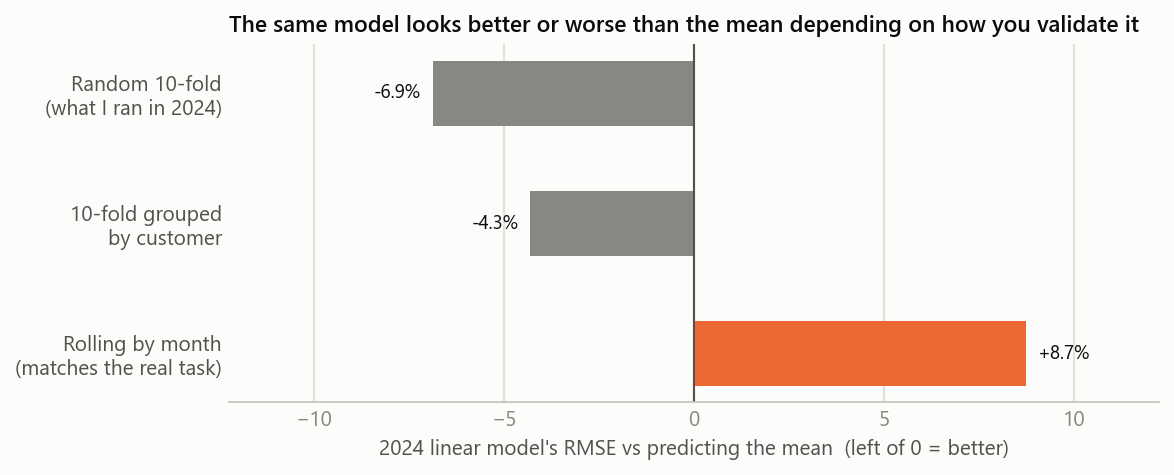

{'random_kfold': -6.89, 'grouped_kfold': -4.33, 'rolling_months': 8.75}

In [6]:
fig("cv_illusion.png")
metrics["cv_illusion_pct_vs_mean"]

**EN —** My notebook printed a 10-fold CV RMSE of 7,015 and I took that as progress. Run the same
random 10-fold on a predict-the-mean baseline and the model looks **6.9% better** than it. Two
leaks produce that illusion. Rows from all months are shuffled together, so the model trains on the
future. And 15,412 customers (10%) appear more than once, so the same person sits on both sides of a fold
(grouping by customer takes away part of the illusion). Validate the way the task actually works and
the sign flips.

**TR —** Notebook'um 10-fold CV RMSE'sini 7.015 olarak yazdırmıştı ve ben bunu ilerleme saymıştım.
Aynı rastgele 10-fold'u ortalamayı tahmin eden baseline'a uygularsanız model ondan **%6,9 daha iyi**
görünüyor. Bu yanılsamayı iki sızıntı üretiyor. Birincisi, tüm ayların satırları karıştırıldığı için
model gelecekle eğitiliyor. İkincisi, 15.412 müşteri (%10) birden fazla kez görünüyor, yani aynı kişi
fold'un iki tarafında da duruyor (müşteriye göre gruplamak yanılsamanın bir kısmını siliyor). Görevin
gerçekte işlediği şekilde doğrulayınca işaret tersine dönüyor.

### Mistakes 3 & 4 — Two real bugs / Hata 3 ve 4 — İki gerçek bug

In [7]:
results.loc[results.key.isin(["1_as_submitted", "2_fix_scaler", "3_fix_refit"]), cols]

,label,dev_rmse,dev_vs_mean_pct,dev_months_beating_mean,holdout_rmse,holdout_vs_mean_pct
1,"My 2024 notebook, replayed exactly","7,413.4",8.7,2,"5,200.8",0.8
2,+ fix: scale the target month with the TRAIN s...,"7,357.4",7.9,2,"5,185.4",0.5
3,"+ fix: refit on all rows, not the last CV fold","7,345.2",7.7,2,"5,226.5",1.3


**EN —**
* **`scaler.fit_transform(df_test)`**: the test month was standardised with *its own* mean and
  standard deviation, so every feature was on a slightly different scale from the one the
  coefficients were learned on. (`month` became 0 everywhere, as if December were July.)
* **The last CV fold's model made the predictions.** The CV loop kept overwriting `model`, and I
  never refit it on all the data, so my submission came from a model that had seen 90% of the rows.

Both were real, and `tests/test_pipeline.py` shows the scaler bug wrecking an otherwise perfect
model. But look at the table: fixing them moves the dev RMSE by less than 1%. **The bugs weren't
why I lost.** The model itself was the problem.

**TR —**
* **`scaler.fit_transform(df_test)`**: test ayı *kendi* ortalaması ve standart sapmasıyla
  ölçeklenmiş. Bu yüzden her özellik, katsayıların öğrenildiği ölçekten biraz farklı bir ölçekteydi.
  (`month` her yerde 0 olmuş; sanki Aralık, Temmuz'muş gibi.)
* **Tahminleri son CV fold'unun modeli yaptı.** CV döngüsü `model`'in üzerine yazıp durmuş, ben de
  onu tüm veriyle yeniden eğitmemişim; yani submission'ım satırların %90'ını görmüş bir modelden gelmiş.

İkisi de gerçek hataydı; `tests/test_pipeline.py` scaler bug'ının kusursuz bir modeli nasıl
bozduğunu gösteriyor. Ama tabloya bakın: ikisini düzeltmek dev RMSE'yi %1'den az oynatıyor.
**Kaybetmemin sebebi bug'lar değildi.** Asıl sorun modelin kendisiydi.

### Mistake 5 — A good idea in the wrong place / Hata 5 — Yanlış yerde iyi bir fikir

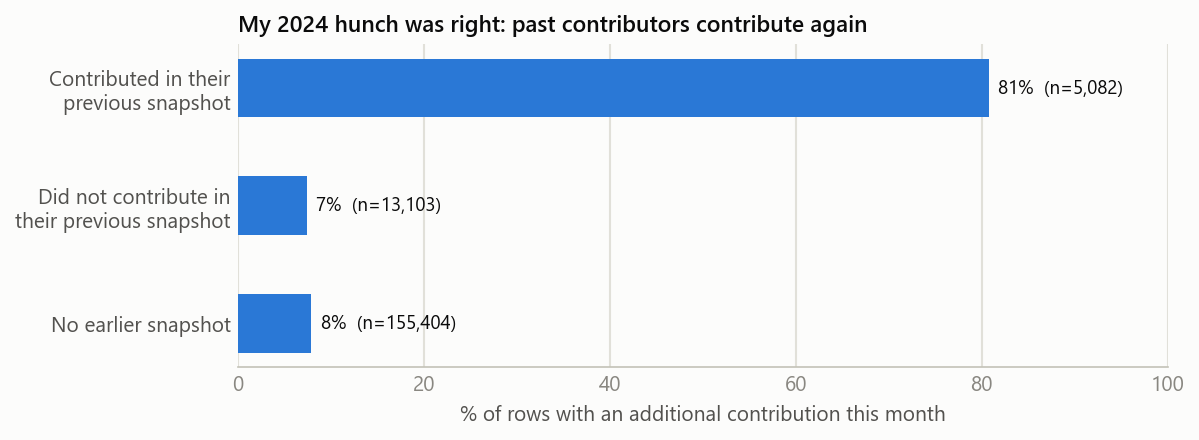

,label,dev_rmse,dev_vs_mean_pct,holdout_rmse,holdout_vs_mean_pct,dev_auc_contributes
0,Final + customer-history features (the overrid...,"6,417.4",-5.9,"4,592.0",-11.0,0.9
1,2024 notebook (bugs fixed) without the override,"6,934.1",1.7,"5,635.8",9.2,0.7
2,2024 notebook (bugs fixed) without RTRNDESVAMNT,"7,336.7",7.6,"5,193.7",0.7,0.8


In [8]:
fig("repeat_signal.png")
checks[["label", "dev_rmse", "dev_vs_mean_pct", "holdout_rmse", "holdout_vs_mean_pct", "dev_auc_contributes"]]

**EN —** My 2024 override replaced the model's prediction with a customer's last positive
contribution. The hunch behind it was **right**: a customer who contributed in their previous
snapshot contributes again ~81% of the time, against ~7% for everyone else. But as a hard override
it is a coin flip under RMSE. Removing it helps on the dev months (+7.7% → +1.7%) and hurts badly
in November (+1.3% → +9.2%). Copying last month's amount is a big bet on exactly the rows that
dominate RMSE.

Turned into features for LightGBM, the same idea **improves who-will-contribute ranking (AUC
0.878 → 0.884)** but leaves the dev RMSE flat (−6.1% → −5.9%). It does look better on November
(−10.4% → −11.0%), but November gets no vote: by my own rule (lowest pooled dev RMSE) it did not
make the final model. Knowing *who* contributes isn't enough; RMSE is decided by
*how much* the few big ones put in.

**TR —** 2024'teki override, modelin tahminini müşterinin son pozitif katkısıyla değiştiriyordu.
Arkasındaki sezgi **doğruydu**: önceki anlık görüntüsünde katkı yapan müşteri, ~%81 ihtimalle yine
katkı yapıyor; diğerlerinde bu oran ~%7. Ama katı bir override olarak RMSE altında yazı tura.
Kaldırınca dev aylarında iyileşiyor (+%7,7 → +%1,7), Kasım'da ise ciddi kötüleşiyor
(+%1,3 → +%9,2). Geçen ayın tutarını kopyalamak, tam da RMSE'yi belirleyen satırlar üzerine
oynanmış büyük bir bahis.

Aynı fikir LightGBM'e özellik olarak verildiğinde **kimin katkı yapacağını sıralamayı iyileştiriyor
(AUC 0,878 → 0,884)**, ama dev RMSE'yi yerinden oynatmıyor (−%6,1 → −%5,9). Kendi kuralıma (en düşük
birleşik dev RMSE) göre bu yüzden final modele girmedi. Kasım'da daha iyi görünüyor (−%10,4 → −%11,0),
ama Kasım'ın oy hakkı yok. *Kimin* katkı yapacağını bilmek yetmiyor;
RMSE'yi birkaç büyük müşterinin *ne kadar* yatırdığı belirliyor.

### Mistake 6 — I trusted a single month / Hata 6 — Tek bir aya güvendim

**EN —** My 2024 feature search trained on March–October and scored ~1,000 feature combinations on
November alone. Its clearest message was "drop `RTRNDESVAMNT`". Tested across all five dev months,
that gain almost vanishes (+7.7% → +7.6%, last row of the checks table above). One whale-dominated
month is not enough evidence to pick features.

**TR —** 2024'teki özellik aramam Mart–Ekim ile eğitip ~1.000 özellik kombinasyonunu yalnızca
Kasım üzerinde puanlıyordu. En net mesajı "`RTRNDESVAMNT`'yi çıkar" oldu. Beş dev ayının hepsinde
test edildiğinde bu kazanç neredeyse yok oluyor (+%7,7 → +%7,6; yukarıdaki kontrol tablosunun son
satırı). Balinaların belirlediği tek bir ay, özellik seçmek için yeterli kanıt değil.

## 6. The rebuild / Yeniden kurulum

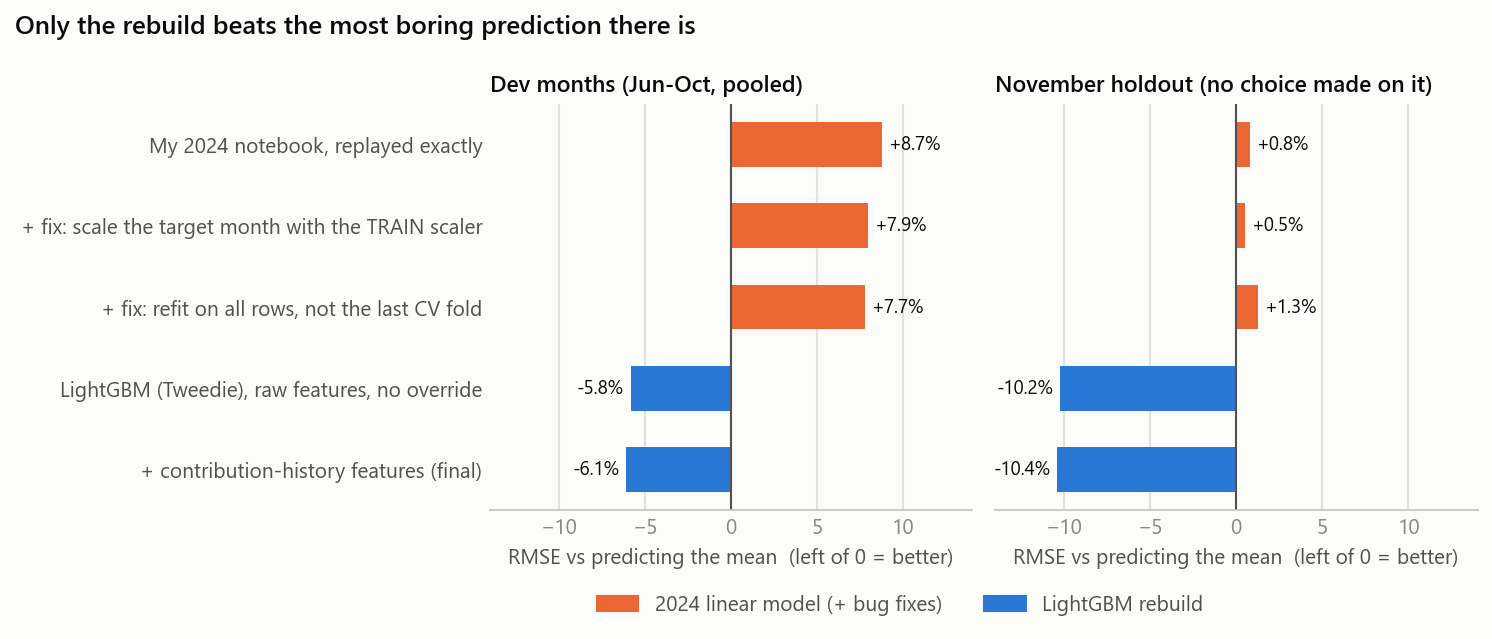

,label,dev_rmse,dev_vs_mean_pct,dev_months_beating_mean,holdout_rmse,holdout_vs_mean_pct,dev_auc_contributes
0,Baseline: predict the training mean,"6,817.1",0.0,0,"5,160.0",0.0,0.5
1,"My 2024 notebook, replayed exactly","7,413.4",8.7,2,"5,200.8",0.8,0.8
2,+ fix: scale the target month with the TRAIN s...,"7,357.4",7.9,2,"5,185.4",0.5,0.8
3,"+ fix: refit on all rows, not the last CV fold","7,345.2",7.7,2,"5,226.5",1.3,0.8
4,"LightGBM (Tweedie), raw features, no override","6,421.5",-5.8,5,"4,633.8",-10.2,0.9
5,+ contribution-history features (final),"6,402.8",-6.1,5,"4,624.7",-10.4,0.9


In [9]:
fig("ladder.png")
results[cols + ["dev_auc_contributes"]]

**EN —** What actually moved the needle was replacing linear regression with **LightGBM using a
Tweedie objective**. Tweedie is designed for exactly this shape ("mostly zeros, then a long
positive tail"). NaNs are left for the trees to route, predictions can't go negative, and extreme
feature values can't blow up a prediction the way they did in the linear model. Adding summaries of
the 11 monthly contribution columns helped a little more.

The final model is **6.1% better than the mean on the dev months and 10.4% better on the November
holdout**, and it beats the mean in all 5 dev months. That may sound modest, but section 3 explains
why nothing here moves by 30%.

**TR —** Asıl farkı yaratan, doğrusal regresyonu **Tweedie objective'li LightGBM** ile değiştirmek
oldu. Tweedie tam olarak bu şekil ("çoğunlukla sıfır, sonra uzun bir pozitif kuyruk") için
tasarlanmış. NaN'ları ağaçlar kendisi yönlendiriyor, tahminler negatife düşemiyor ve uç özellik
değerleri, doğrusal modelde olduğu gibi tahmini patlatamıyor. 11 aylık katkı sütununun özetlerini
eklemek de biraz daha katkı sağladı.

Final model **dev aylarında ortalamadan %6,1, Kasım holdout'unda %10,4 daha iyi** ve 5 dev ayının
hepsinde ortalamayı geçiyor. Mütevazı görünebilir, ama burada hiçbir şeyin neden %30 oynamadığını
bölüm 3 açıklıyor.

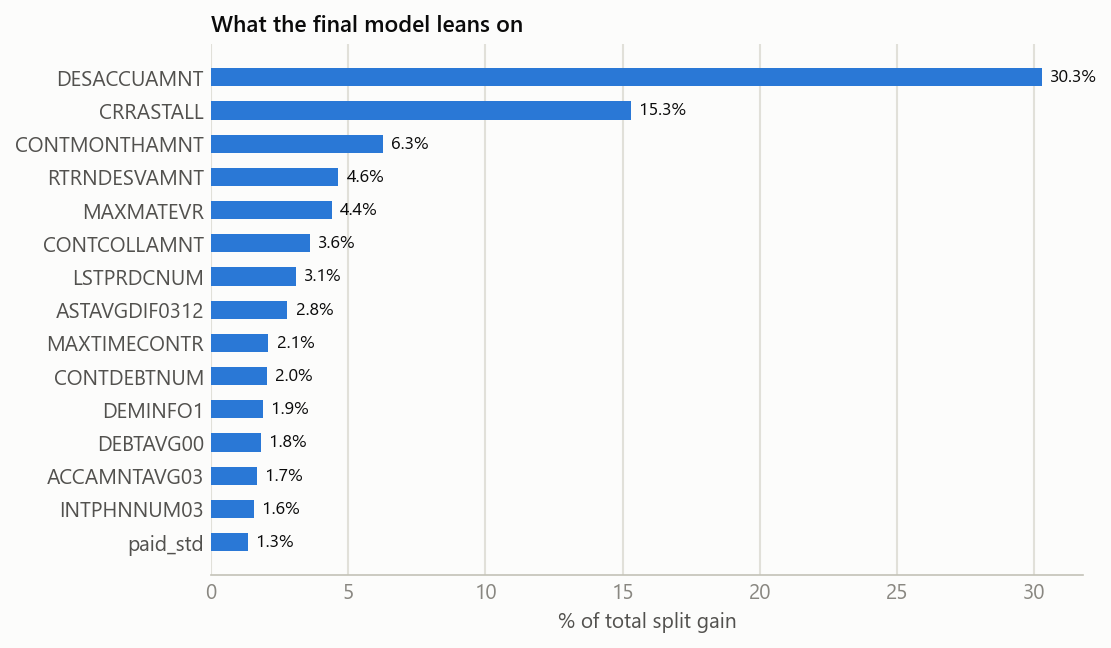

In [10]:
fig("feature_importance.png")

## 7. What I can't claim / İddia edemeyeceklerim

**EN —** The test labels were never released, so I can't tell you what the rebuild would have
scored on the leaderboard. `train.py` writes `submissions/submission_final.csv` (and the exact 2024
replay next to it), so the honest next step is a late submission. On the validation I *can* run,
the rebuild goes from 8.7% worse than a constant to 6.1% better than it on the dev months, and
from +0.8% to −10.4% on November.

**TR —** Test etiketleri hiç yayımlanmadı, dolayısıyla yeni modelin leaderboard'da ne alacağını
söyleyemem. `train.py`, `submissions/submission_final.csv` dosyasını (yanına da 2024'ün birebir
tekrarını) yazıyor; dürüst bir sonraki adım geç gönderim yapmak. *Yapabildiğim* doğrulamada ise
yeni model, dev aylarında sabit tahminden %8,7 kötü olmaktan %6,1 iyi olmaya; Kasım'da +%0,8'den
−%10,4'e geçiyor.

In [11]:
metrics["test_prediction_mean"]

{'final': 787.6, 'replay_2024': 1265.4, 'train_target_mean': 782.9}